# Introduction to Statistic & Machine learning

In this lab, we are going to talk about some primitive things that you must understand to understand the concept of machine learning, as you might know, Machine Learning is a fancy statistics course.

## Outline
* Learn how to load a dataset.
* Learn how to organize data.
* Understand the basics behind ML.
* Be able to visualize your results.


## 1: Importing libraries
The next code will contain the imports of various libraries, starting from NumPy, which is an essential library for our lab.

In [1]:
import numpy as np
import matplotlib as mpl   
import matplotlib.pyplot as plt
import gzip

## 2: The MNIST Database
The MNIST database is a collection of handwritten digits, each digit is a 28x28 pixel image, the database has two sets, the first one for training, which contains 60,000 photos, and the other is for testing and contains 10,000 photos.

You can download the database from here: http://yann.lecun.com/exdb/mnist/

*Note:* The database is already in your lab zip file.

### Loading the database 
To load the database, we will look at the format of these files, go to their website at `FILE FORMATS FOR THE MNIST DATABASE`, you should understand the following code from it!

In [ ]:
def load_mnist (images_gz, lables_gz):
  f = gzip.open(images_gz,'r') # Open the image gzip file  using gzip module 
  f.read(4) # Read the magic number
  num_images = int.from_bytes(f.read(4), byteorder='big') # Read the number of images
  f.read(8) # Ignore the last 8 bytes, which contains width and height as we know its 28x28
  image_size = 28
  
  buf = f.read(image_size * image_size * num_images)
  # Convert the buffer (just bytes) to a NumPy array and convert it to float32 to do some manipulation later
  images = np.frombuffer(buf, dtype=np.uint8).astype(np.float32)
  # Reshape the array to a matrix with the shape (num_image, 28, 28)
  images = images.reshape(num_images, image_size, image_size)

    
  f = gzip.open(lables_gz,'r')
  f.read(4) # Read the magic number
  num_lables = int.from_bytes(f.read(4), byteorder='big') 

  buf = f.read(num_images)
  labels = np.frombuffer(buf, dtype=np.uint8)
  
  return (images, labels)

In [3]:
(train_images, train_labels) = load_mnist("train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz")
print(train_images.shape)
print(train_labels.shape)

(60000, 28, 28)
(60000,)


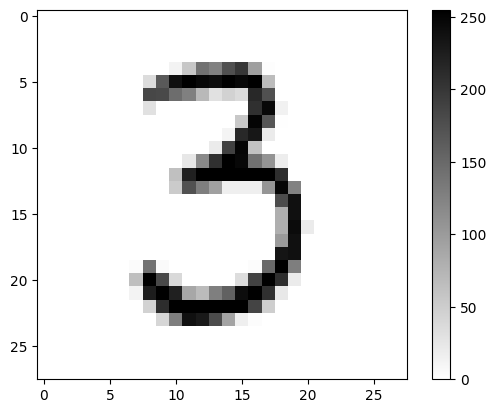

Image label: 3


In [8]:
plt.imshow(train_images[50], cmap='gray_r')
plt.colorbar()
plt.show()
print("Image label: "+str(train_labels[50]))

Notice that the first item in the training data is the number 5, you could filter all the images with the number 5 using a simple python selector!

### Task 1: Create a function that gets all images of number `n`.

In [6]:
def get_n_images(n):
  # Place your code here!
  return train_images[train_labels == n]

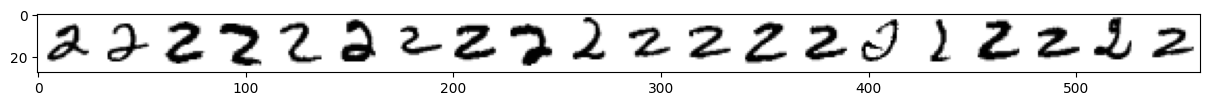

Pilots!


In [ ]:
ones = get_n_images(2)
twenty_one = np.empty((28,0))
for i in range(20):
  twenty_one = np.hstack((twenty_one, ones[i]))  #hstack = horizontal Append each 2 image horizontally to form a single row image of 20 images
plt.figure(figsize=(15,2))
plt.imshow(twenty_one, cmap='gray_r')
plt.show()
print("Pilots!")

### Task 2: Create a list of NumPy arrays, which index n contains the array of number `n` images.

In [13]:
images_by_label = []
# Place your co`de here!
images_by_label = []
for i in range(10):
  images_by_label.append(get_n_images(i))


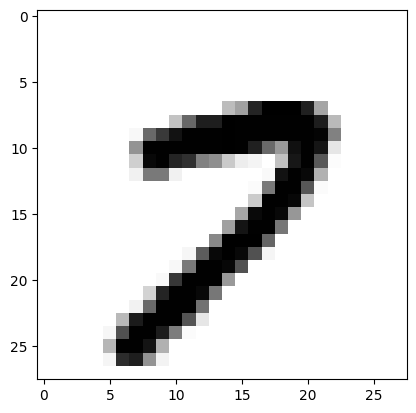

In [ ]:
plt.imshow(images_by_label[7][100], cmap='gray_r')
plt.show()

### Mean of images
As you all know, we can get the mean of an array of number by dividing the sum of all numbers by their count, or we can simply write it like this:

<br/>
<center style="font-size:20px">
$mean = {{1}\over{n}} \sum_{n=1}^{\infty} {y_n}$
</center>
<br/>

The mean of the images of number `1` will show us an image that indicates the most common writing of number `1`.

### Task 3: Get the mean of number `1` and `2`.
*Note:* Use what NumPy offers!

In [16]:
def get_n_mean(n):
  # Place your code here!
  images = get_n_images(n)
  return np.mean(images, axis=0)

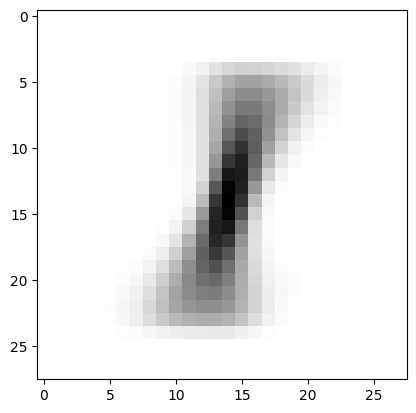

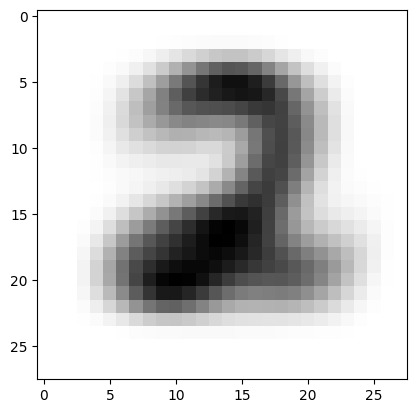

In [17]:
plt.imshow(get_n_mean(1), cmap='gray_r')
plt.show()
plt.imshow(get_n_mean(2), cmap='gray_r')
plt.show()

### Creating an array of means images

In [18]:
numbers_means = np.empty((10, 28, 28))  # matrix to hold mean images for digits 0-9 in size 28*28
for i in range(10):
  numbers_means[i] = get_n_mean(i)

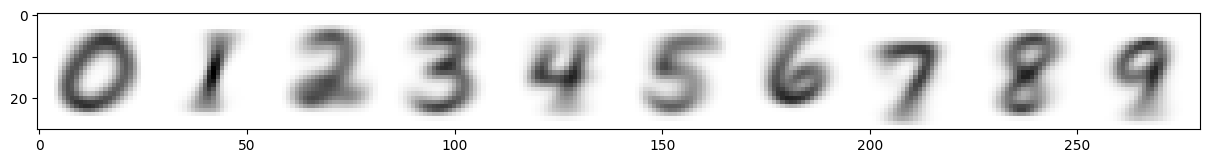

In [ ]:
means = np.concatenate(numbers_means, axis=1) # concatenate all mean images horizontally to form a single row image 
plt.figure(figsize=(15,2))
plt.imshow(means, cmap='gray_r')
plt.show()

## 3: Making simple predictions!

In this section, you should load the testing dataset, then you should create a function that depends on the mean of each number to predict the number for only its image
### Loading Test Data

In [20]:
(test_images, test_labels) = load_mnist("t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz")
print(test_images.shape)
print(test_labels.shape)

(10000, 28, 28)
(10000,)


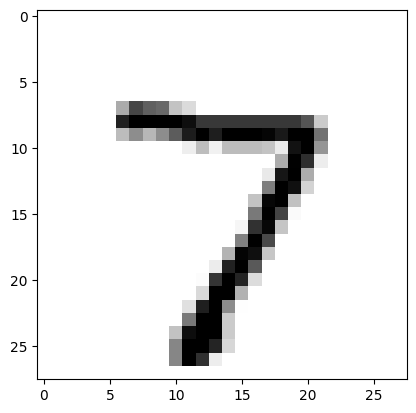

In [21]:
plt.imshow(test_images[0], cmap='gray_r')
plt.show()

As you noticed, the first element in the testing set is number `7`, try to get the `Mean absolute error` between this image, and all items in the `numbers_means` array.

<br/>
<center style="font-size:20px">
$MAE = {{1}\over{n}} \sum_{i=1}^{n}\left | y_{i} - x_{i} \right |$
<img src = "./mean_error.png"></img>
</center>
<br/>

In [22]:
test_image = test_images[0]
## This could be achieved using loops
test_mae = np.abs(numbers_means[:] - test_image).mean(axis=(1,2))
print(test_mae)

[45.12235047 31.96304293 41.65767869 39.20587952 33.72576866 37.51915712
 41.66202548 22.28824131 38.95530267 29.79163945]


What is the index of the smallest number?

You could use `np.argmin` to get the index of the minimum value.

In [23]:
print ("Prediction: " + str(np.argmin(test_mae)))
print ("Real Label: " + str(test_labels[0]))

Prediction: 7
Real Label: 7


### Task 4: Create a prediction function that returns a lable

In [24]:
def predict (test_image):
  # Place your code here!
  mae_values = np.abs(numbers_means - test_image).mean(axis=(1, 2))
  return np.argmin(mae_values)

In [25]:
for i in range(10):
  print("Image "+ str(i) +" - Label: "+ str(test_labels[i]) +" - Prediction: "+ str(predict(test_images[i])))

Image 0 - Label: 7 - Prediction: 7
Image 1 - Label: 2 - Prediction: 1
Image 2 - Label: 1 - Prediction: 1
Image 3 - Label: 0 - Prediction: 0
Image 4 - Label: 4 - Prediction: 4
Image 5 - Label: 1 - Prediction: 1
Image 6 - Label: 4 - Prediction: 4
Image 7 - Label: 9 - Prediction: 9
Image 8 - Label: 5 - Prediction: 1
Image 9 - Label: 9 - Prediction: 9


Now, we can do better with a little tweak, we will use `Mean square error`, which will square every error, so bigger errors will have more weight. 

<br/>
<center style="font-size:20px">
$MSE = {{1}\over{n}} \sum_{i=1}^{n} (y_{i} - x_{i})^2$
<br/>
<img src = "./mea_error2.png"></img>
</center>
<br/>

In [60]:
test_image = test_images[0]
## This could be achieved using loops
test_mse = ((numbers_means[:] - test_image) ** 2).mean(axis=(1,2))
print(test_mse)

[6009.81779737 5135.89921243 5109.71352863 4941.69356234 4070.75959656
 4379.03794794 5608.89164749 1902.54628649 4907.44995607 3415.07286826]


### Task 5: Rewrite the prediction function using `MSE`

In [26]:
def predict (test_image):
  # Place your code here!
  mse_values = ((numbers_means - test_image) ** 2).mean(axis=(1, 2))
  return np.argmin(mse_values)

In [27]:
for i in range(10):
  print("Image "+ str(i) +" - Label: "+ str(test_labels[i]) +" - Prediction: "+ str(predict(test_images[i])))

Image 0 - Label: 7 - Prediction: 7
Image 1 - Label: 2 - Prediction: 2
Image 2 - Label: 1 - Prediction: 1
Image 3 - Label: 0 - Prediction: 0
Image 4 - Label: 4 - Prediction: 4
Image 5 - Label: 1 - Prediction: 1
Image 6 - Label: 4 - Prediction: 4
Image 7 - Label: 9 - Prediction: 9
Image 8 - Label: 5 - Prediction: 2
Image 9 - Label: 9 - Prediction: 9


## 4: Visualizing our results
In this section, we will try to get how good is our model, what is the number of correct predictions, and what are the numbers that our model could not recognize correctly.

### Get all the predicted labels from the test set
The first thing we will do is to get all the predictions, this could be simply a for-loop, or you can tweak your NumPy formula to get it faster!

In [28]:
predicted_labels = np.empty(test_labels.shape, dtype=test_labels.dtype)
for i in range(len(predicted_labels)):
  predicted_labels[i] = predict(test_images[i])
    
print("We have "+str(len(predicted_labels)) + " predicted labels")
for i in range(20):
  print("Image "+ str(i).zfill(2) +" - Label: "+ str(test_labels[i]) +" - Prediction: "+ str(predicted_labels[i]))

We have 10000 predicted labels
Image 00 - Label: 7 - Prediction: 7
Image 01 - Label: 2 - Prediction: 2
Image 02 - Label: 1 - Prediction: 1
Image 03 - Label: 0 - Prediction: 0
Image 04 - Label: 4 - Prediction: 4
Image 05 - Label: 1 - Prediction: 1
Image 06 - Label: 4 - Prediction: 4
Image 07 - Label: 9 - Prediction: 9
Image 08 - Label: 5 - Prediction: 2
Image 09 - Label: 9 - Prediction: 9
Image 10 - Label: 0 - Prediction: 0
Image 11 - Label: 6 - Prediction: 2
Image 12 - Label: 9 - Prediction: 9
Image 13 - Label: 0 - Prediction: 0
Image 14 - Label: 1 - Prediction: 1
Image 15 - Label: 5 - Prediction: 5
Image 16 - Label: 9 - Prediction: 9
Image 17 - Label: 7 - Prediction: 7
Image 18 - Label: 3 - Prediction: 3
Image 19 - Label: 4 - Prediction: 4


### Accuracy
The accuracy of our model will be

<br/>
<center style="font-size:18px">
$accuracy = correct predictions / total number of samples$
</center>
<br/>

In [29]:
correct_predictions = np.sum(predicted_labels == test_labels)
accuracy = correct_predictions / len(predicted_labels)
print("Model accuracy = "+str(accuracy*100) + "%")

Model accuracy = 82.03%


#### Is accuracy a good measure for every system?
No, Imagine if you're creating a system to detect a rare disease, something like one in every one million people has this disease, if your model is just a function that returns `negative`, you will have 99.9999% accuracy!

### Confusion matrix
The confusion matrix is one of the most visually appealing methods to know how is your system doing, to create a confusion matrix, we will create a matrix, which has the shape `nXn` where `n` is the number of classes.
We will assume that the rows are the true labels, and the columns are the predicted labels.

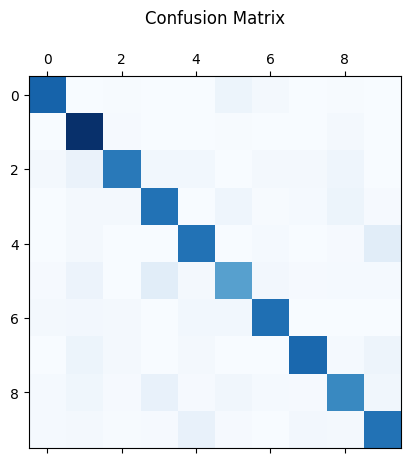

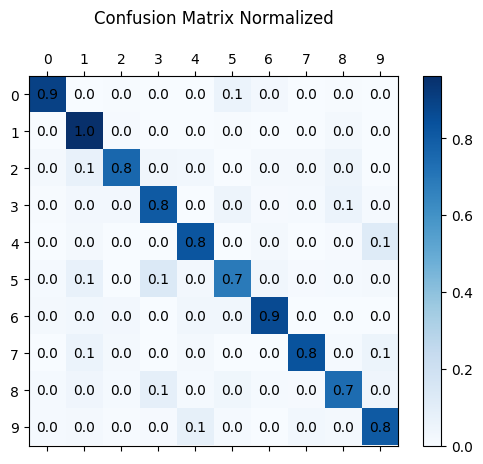

In [30]:
confusion = np.zeros(shape=(10, 10))
confusion_normilized = np.zeros(shape=(10, 10))
for true_label in range (10):
  for predicted_label in range(10):
    confusion[true_label, predicted_label] = np.sum (np.logical_and(predicted_labels == predicted_label, test_labels == true_label))
  confusion_normilized[true_label, :] = confusion[true_label, :] / np.sum(test_labels == true_label)

plt.matshow(confusion, cmap='Blues')
plt.title("Confusion Matrix\n")
plt.show()

ax = plt.subplot()
ix = ax.matshow(confusion_normilized, cmap='Blues')
for (i, j), z in np.ndenumerate(confusion_normilized):
  ax.text(j, i, '{:0.1f}'.format(z), ha='center', va='center')
    
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar(ix)
plt.title("Confusion Matrix Normalized\n")
plt.show()


<center>
    <h4>End of Lab 3</h4>
</center>